In [ ]:
import numpy as np
import cv2

image = cv2.imread('/data/zhouziyu/home3/zhouziyu/warmup/sslpretrain/Swin-Transformer/figures/gradcam/dino_gradcam/00000032_037.png')
# image = image*255
image[image<200]=0
image[image>=200]=255
print(image.shape)
contours, _ = cv2.findContours(image[:,:,0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
bounding_boxes = [cv2.boundingRect(c) for c in contours]
print(bounding_boxes)
cv2.imwrite('test.png', image)
print(np.unique(image))

In [2]:
import cv2
image = cv2.imread('/sda1/zhouziyu/ssl/dataset/NIHChestX-ray14/images/00000181_042.png')
print(image.shape)

[ WARN:0@0.009] global loadsave.cpp:241 findDecoder imread_('/sda1/zhouziyu/ssl/dataset/NIHChestX-ray14/images/00000181_042.png'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
t1 = open('/data/zhouziyu/home3/zhouziyu/warmup/sslpretrain/Swin-Transformer/figures/gradcam/bbox_list_withgt.txt', 'w')
with open('/data/zhouziyu/home3/zhouziyu/warmup/sslpretrain/Swin-Transformer/figures/gradcam/bbox_list.txt', 'r') as f1:
    for line in f1:
        imagename = line.split(' ')[0]
        with open('/data/zhouziyu/home3/zhouziyu/warmup/sslpretrain/BenchmarkTransformers/dataset/Xray14_test_official.txt', 'r') as f2:
            # print(imagename)
            for line2 in f2:
                
                if line2.split(' ')[0]==imagename:
                    print(imagename, line2.split(' ')[0])
                    t1.writelines(line2)
t1.close()

In [ ]:
import shutil
import os

src_path = '/sda1/zhouziyu/ssl/dataset/NIHChestX-ray14/images'
tar_path = '/data/zhouziyu/home3/zhouziyu/warmup/sslpretrain/visualization/images/image_landmark'
for i in os.listdir('/data/zhouziyu/home3/zhouziyu/warmup/sslpretrain/visualization/images/image_7landmarks'):
    shutil.copy(os.path.join(src_path, i), os.path.join(tar_path,i))

In [ ]:
import cv2

image = cv2.imread('/data/zhouziyu/home3/zhouziyu/warmup/sslpretrain/visualization/images/image_landmark/00000252_001.png')
image = cv2.resize(image, (448,448))
cv2.imwrite('/data/zhouziyu/home3/zhouziyu/warmup/sslpretrain/visualization/co-segmentation/root_image/set5_448/00000252_001.png', image)

In [ ]:
import cv2
img1 = cv2.imread('/sda1/zhouziyu/ssl/dataset/FIRE/Images/A09_1.jpg')
img2 = cv2.imread('/sda1/zhouziyu/ssl/dataset/FIRE/Images/A09_2.jpg')
f = open('/sda1/zhouziyu/ssl/dataset/FIRE/Ground Truth/control_points_A09_1_2.txt')

color_dict = {
    'blue': (255, 0, 0),
    'red': (0, 0, 255),
    'green': (0, 255, 0),
    'yellow': (0, 255, 255),
    'orange': (0, 165, 255),
    'purple': (128, 0, 128),
    'magenta': (255, 0, 255),
    'pink': (203, 192, 255),
    'cyan': (255, 255, 0),
    'tan': (180, 229, 255),
    'thistle': (216, 191, 216),
    'honeydew': (240, 255, 240),
    'orchild': (214, 112, 218)
    }
colors = ['blue', 'red', 'green', 'yellow', 'orange', 'purple', 'magenta','pink', 'cyan', 'tan', 'thistle','honeydew','orchild']

line_number = 0
for i in f:
    color = color_dict[colors[line_number]]
    label = i.strip()
    label = label.split(' ')
    print(label)
    cv2.circle(img1, (int(float(label[0])),int(float(label[1]))), 60, color, -1)  # yellow cicle
    cv2.circle(img2, (int(float(label[2])),int(float(label[3]))), 60, color, -1)  # yellow cicle
    line_number+=1

cv2.imwrite('./correspondence_fundus/A09_1.jpg', img1)
cv2.imwrite('./correspondence_fundus/A09_2.jpg', img2)

In [ ]:
import matplotlib.pyplot as plt

# 定义点的坐标
points = [(647, 462), (462, 480), (409, 329)]
points2 = [(499.8,422)]

import matplotlib.pyplot as plt


# 创建一个图形和坐标轴
fig, ax = plt.subplots()

# 解包点的坐标，用于绘制
x, y = zip(*points)

# 绘制三个点
ax.plot(x, y, 'yo')  # 使用红色圆点标记顶点


x, y = zip(*points2)
ax.plot(x, y, 'ro')  # 使用红色圆点标记顶点

# 连接三个点以形成三角形，包括连接最后一个点和第一个点
ax.plot(*zip(*points, points[0]), 'b-')  # 使用蓝色线条连接点

# 设置图形的标题和坐标轴标签
ax.set_title('Triangle with Vertices')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

# 设置坐标轴的刻度以更好地显示点
ax.axis('equal')  # 使x和y轴的刻度间隔保持一致

# 显示图形
plt.show()



In [ ]:
def find_intersection(x1, y1, x2, y2, x3, y3, x4, y4):
    import numpy as np
    
    # 解析直线方程的系数
    def line_coefficients(x1, y1, x2, y2):
        A = y2 - y1
        B = x1 - x2
        C = A * x1 + B * y1
        return A, B, C

    # 打印输入点坐标
    print(f"Line 1 from ({x1}, {y1}) to ({x2}, {y2})")
    print(f"Line 2 from ({x3}, {y3}) to ({x4}, {y4})")

    # 计算两条线的系数
    A1, B1, C1 = line_coefficients(x1, y1, x2, y2)
    A2, B2, C2 = line_coefficients(x3, y3, x4, y4)
    
    print(f"Line 1 coefficients: {A1}, {B1}, {C1}")
    print(f"Line 2 coefficients: {A2}, {B2}, {C2}")

    # 构建系数矩阵和常数向量
    coefficients = np.array([[A1, B1], [A2, B2]])
    constants = np.array([C1, C2])

    # 使用numpy求解线性方程组
    try:
        intersection = np.linalg.solve(coefficients, constants)
        print(f"Intersection: {intersection}")
        return intersection
    except np.linalg.LinAlgError:
        print("Lines do not intersect")
        return None  # 如果直线平行或重合，返回None

# 使用示例
A = (1, 2)
B = (4, 3)
C = (3, 5)
P = (2, 3)

A1 = find_intersection(A[0], A[1], P[0], P[1], B[0], B[1], C[0], C[1])
B1 = find_intersection(B[0], B[1], P[0], P[1], A[0], A[1], C[0], C[1])
C1 = find_intersection(C[0], C[1], P[0], P[1], A[0], A[1], B[0], B[1])


In [ ]:
import numpy as np

# 定义系数矩阵 A
A = np.array([[3, 4],
              [2, -1]])

# 定义常数向量 B
B = np.array([5, 1])

# 求解线性方程组
X = np.linalg.solve(A, B)

print("解向量 X:", X)


In [ ]:
import pandas as pd

# 数据标签
labels = ['ChestX-ray14','RSNA','Shenzhen','CheXpert','JSRT Heart','JSRT Clavicle','VinDr-Rib','SIIM','COVID-QU-Ex','BLUE-3','BLUE-4',
          'ROUGE-L','BERTScore-F1','DNA-test','Triangulation']

# 五组数据
values1 = [83.4, 74.79, 98.18, 89.53, 95.35, 93.33, 71.13, 81.19, 86.67, 21.36, 15.8, 39.87, 36.62, 88.54, 90.7]
values2 = [80.48, 73.44, 95.61, 88.24, 94.9, 91.74, 66.93, 78.89, 84.78, 20.84, 15.27, 37.6, 35.4, 82.66, 83.8]
values3 = [82.78, 74.39, 97.39, 88.81, 95.21, 92.19, 66.4, 78.97, 85.27, 18.53, 13.29, 36.2, 34.08, 58.06, 86.3]
values4 = [81.84, 73.78, 96.97, 88.16, 94.63, 91.77, 63.77, 78.65, 84.58, 21.33, 15.18, 37.3, 36.34, 60.09, 70.6]
values5 = [83.11, 74.33, 97.77, 88.82, 94.86, 92.87, 66.46, 79.64, 86.42, 15.92, 11.47, 33.14, 30.85, 71.4, 73]

# 创建DataFrame
data = {
    'Label': labels,
    'Lamps': values1,
    'DINO': values2,
    'PEAC': values3,
    'POPAR': values4,
    'RAD-DINO': values5
}

df = pd.DataFrame(data)

# 保存为CSV文件
df.to_csv('model_performance.csv', index=False)

print("CSV文件已保存为 'model_performance.csv'")





In [ ]:
import torch
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
data1 = torch.load('/mnt/sda/zhouziyu/ssl/datasets/ChestXray/NIHChestX-ray14/landmark_embd_large_fromMIM_extrap_shuffle_consis_compdecomp_5imgs/00000001_000.png.npy')
data2 = torch.load('/mnt/sda/zhouziyu/ssl/datasets/ChestXray/NIHChestX-ray14/landmark_embd_large_fromMIM_extrap_shuffle_consis_compdecomp_5imgs/00000001_001.png.npy')
data3 = torch.load('/mnt/sda/zhouziyu/ssl/datasets/ChestXray/NIHChestX-ray14/landmark_embd_large_fromMIM_extrap_shuffle_consis_compdecomp_5imgs/00000002_000.png.npy')
data4 = torch.load('/mnt/sda/zhouziyu/ssl/datasets/ChestXray/NIHChestX-ray14/landmark_embd_large_fromMIM_extrap_shuffle_consis_compdecomp_5imgs/00000008_001.png.npy')
data5 = torch.load('/mnt/sda/zhouziyu/ssl/datasets/ChestXray/NIHChestX-ray14/landmark_embd_large_fromMIM_extrap_shuffle_consis_compdecomp_5imgs/00000143_009.png.npy')
data_list = [data1, data2, data3, data4, data5]

# 将每个数据重塑为二维数组，并存入列表
reshaped_data_list = [data.reshape(-1, data.shape[-1]) for data in data_list]

# 将所有数据垂直堆叠，形成一个大的二维数组，形状为 (16384*5, 1024)
combined_data = np.vstack(reshaped_data_list)

# 使用 KMeans 进行聚类，聚为 8 类
k = 8
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(combined_data)
combined_labels = kmeans.labels_

# 将聚类标签拆分回每个数据集，并重塑为 (128,128)
labels_list = []
start = 0
for data in data_list:
    num_pixels = data.shape[0] * data.shape[1]
    labels = combined_labels[start:start + num_pixels]
    labels_image = labels.reshape(data.shape[0], data.shape[1])
    labels_list.append(labels_image)
    start += num_pixels

# 创建一个包含 8 种颜色的颜色映射
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'black', 'white']
cmap = ListedColormap(colors[:k])

# 绘制并保存每个数据的聚类结果
for idx, labels_image in enumerate(labels_list):
    plt.figure(figsize=(6, 6))
    plt.imshow(labels_image, cmap=cmap, interpolation='nearest')
    plt.colorbar(ticks=range(k))
    plt.title(f'Clustering Result for Data {idx + 1}')
    plt.axis('off')
    plt.savefig(f'clustering_result_{idx + 1}.png', bbox_inches='tight', pad_inches=0)
    plt.show()

In [1]:
# load label of PAX-RAY++ dataset
# code from https://www.kaggle.com/code/agustinbottos/pax-ray-visualizer-and-model
import pandas as pd
import json

paxray_test = '/mnt/sda/zhouziyu/ssl/datasets/ChestXray/PAX_RAY/paxray_test.json'
with open(paxray_test, 'r') as f:
    data = json.load(f)

data_image = data['images']
data_categories = data['categories']
data_anno = data['annotations']
print(data_image[0])
print(data_categories[0])
print(data_anno[0])

df_annotations = pd.DataFrame(data_anno)
df_annotations.head()

df_images = pd.DataFrame(data_image)
df_images.head()

df_categories = pd.DataFrame(data_categories)
df_categories.head()

df_merged = pd.merge(df_annotations, df_categories, left_on='category_id', right_on='id')
df_merged = pd.merge(df_merged, df_images, left_on='image_id', right_on='id')
df_merged.to_csv('paxray_merged.csv', index=False)

{'id': 7535, 'file_name': 'RibFrac_056_frontal.png', 'height': 512, 'width': 512, 'date_captured': ''}
{'supercategory': 'spine', 'id': 0, 'name': 'spine'}
{'id': 1, 'image_id': 0, 'category_id': 0, 'segmentation': {'size': [512, 512], 'counts': '^eX24g?8M2aAIQ=9kBLo<:lBL0Ai9OaGd0fNLNG_8JgG;m0:lNKNK<En66kH5Q15oN0MN5Hj65PI4U11oN0MN3Jl63PI40@;a0G2MN2N3Ff57VJ40B9?F2101L0Ii54VJ40E6<G25M01MK3Kc45[K40LM255MN3ON1OF51[34aL4K12M37MN5MN1OF51[34aL4K1O7J27K4L30H01O2H`0KEO2:L0O2N=DO5N9I50F01O0L>KG0O510O2L?A46F>L11IM1O0L92JKO330O0Lc0A50F?K7NKNNONN;3DN2M60M2Nk1_OcN?N6G00LOK3<ND02M8NJ>Ee22`M<D2NLOK644HG4O:LJ>Cg22`M;E1OMNN344HG4O7OMU4@`L<A:0F00144HG4M73M]5GjJ<NKON144HG4K9>^OX52kJ9H30K144HG4K9`0\\OV5ORK:C50MO44HD7N6o7B_H500L44HB904o7@]H;2LL26J@920o7B]H;N2NN6J@67NR9LUG4022J@490S9FUG:M02N@290V:0oE000B0e0Dj9<oE00ND2b;KoD5KKG5a;ImD7KKG5f;DhD<KKG0n<5[CKG0[5N[1:cIHG0X51UKMR5:jJFI2S4LVL50O[5LdK4i20VL300\\7M^L0VL5L0`7K]KIZM<H0N57DW62bLLWM9I5M0:DW62bLLWM>F01M9IU6NfL2QM:MM005IY6JaK1]N5G:4FI:2IP9KWG5L24II:0M8De77X

In [9]:
print(df_merged.iloc[0])

id_x                                                             1
image_id                                                         0
category_id                                                      0
segmentation     {'size': [512, 512], 'counts': '^eX24g?8M2aAIQ...
area                                                         34591
bbox                                    [145.0, 0.0, 109.0, 512.0]
iscrowd                                                          0
supercategory                                                spine
id_y                                                             0
name                                                         spine
id                                                               0
file_name             RSNAPE_e00426c826fc_d5fc2b9007a7_lateral.png
height                                                         512
width                                                          512
date_captured                                                 

id_x                                                       2256586
image_id                                                     12749
category_id                                                     12
segmentation     {'size': [512, 512], 'counts': 'hPk22n?6J3L2O2...
area                                                          2929
bbox                                    [182.0, 23.0, 113.0, 50.0]
iscrowd                                                          0
supercategory                                         vertebrae T2
id_y                                                            12
name                                                  vertebrae T2
id                                                           12749
file_name                                  RibFrac_358_frontal.png
height                                                         512
width                                                          512
date_captured                                                 

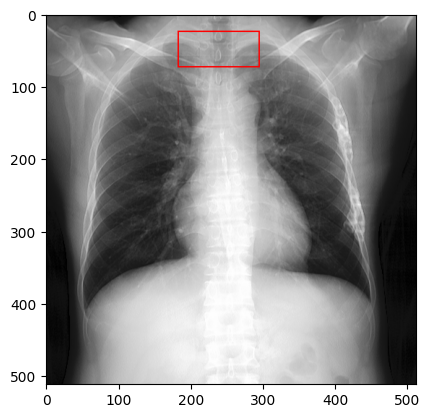

In [26]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
def visualizer(row):
    # Extract the row information
    print(row)
    bbox = row['bbox']
    file_name = row['file_name']

    # Load the image
    image_path = f"/mnt/sda/zhouziyu/ssl/datasets/ChestXray/PAX_RAY/images_patlas/images_patlas/{file_name}"
    image = Image.open(image_path)
    # Draw the bounding box on the image
    draw = ImageDraw.Draw(image)
    x, y, width, height = bbox
    draw.rectangle([x, y, x + width, y + height], outline="red", width=2)

    # Display the image
    plt.imshow(image)
    
visualizer(df_merged.iloc[158378])

In [27]:
# save the image with bounding box
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import os

# 过滤出 file_name 为目标图像的行
target_file_name = 'RibFrac_358_frontal.png'
filtered_df = df_merged[df_merged['file_name'] == target_file_name]

# 图像目录（你需要修改为真实路径）
images_dir = '/mnt/sda/zhouziyu/ssl/datasets/ChestXray/PAX_RAY/images_patlas/images_patlas/' 
save_dir = '/mnt/sda/zhouziyu/ssl/datasets/ChestXray/PAX_RAY/images_patlas/bbox_example'
image_path = os.path.join(images_dir, target_file_name)

# 读取图像（注意：cv2 读取的是 BGR，matplotlib 显示需要 RGB）
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 遍历每一行，画框并保存
for idx, row in filtered_df.iterrows():
    fig, ax = plt.subplots(1)
    ax.imshow(image_rgb)

    # 取出 bbox 和 name
    bbox = row['bbox']  # 格式为 [x, y, width, height]
    name = row['name']

    # 画矩形框
    rect = patches.Rectangle(
        (bbox[0], bbox[1]), bbox[2], bbox[3],
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

    # 保存图像为 name.png
    output_path = f'{save_dir}/RibFrac_358_frontal_{name}.png'
    plt.axis('off')
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

In [6]:
import pandas as pd
import os

# 创建保存 txt 的目录
output_dir = '/mnt/nvme1n1/zhouziyu/visualization/correspondence/PAX_RAY_spine_query_key/query'
key_dir = '/mnt/nvme1n1/zhouziyu/visualization/correspondence/PAX_RAY_spine_query_key/key'
os.makedirs(output_dir, exist_ok=True)

# 1. 筛选出 file_name 包含 'frontal' 的行
df_frontal = df_merged[df_merged['file_name'].str.contains('frontal')]

# 2. 获取不重复的 file_name 列表，并取前100个
frontal_filenames = df_frontal['file_name'].unique().tolist()[203:208]
print(frontal_filenames)

# 3. 遍历这些 file_name
for fname in frontal_filenames:
    # 筛选出当前 file_name 对应的所有行
    rows = df_frontal[df_frontal['file_name'] == fname]
    
    # 4. 筛选出 name 为 vertebrae T1 - vertebrae T12 的行
    vertebrae_names = [f'vertebrae T{i}' for i in range(1, 13)]
    vertebrae_rows = rows[rows['name'].isin(vertebrae_names)]
    
    # 5. 提取 bbox 列，转为字符串
    bbox_list = vertebrae_rows['bbox'].tolist()
    bbox_lines = [str(bbox) for bbox in bbox_list]
    if len(bbox_lines)<12:
        print(f"Warning: {fname} has less than 12 vertebrae bounding boxes.")
        continue

    # 保存为 txt 文件
    out_path = os.path.join(output_dir, f'{fname}.txt')
    # 去除文件名中可能的路径或斜杠
    safe_out_path = os.path.join(output_dir, f"{os.path.basename(fname).replace('/', '_')}.txt")

    with open(safe_out_path, 'w') as f:
        f.write('\n'.join(bbox_lines))
        

# frontal_filenames = df_frontal['file_name'].unique().tolist()[100:203]
# print(frontal_filenames)

# 3. 遍历这些 file_name
# for fname in frontal_filenames:
#     # 筛选出当前 file_name 对应的所有行
#     rows = df_frontal[df_frontal['file_name'] == fname]
    
#     # 4. 筛选出 name 为 vertebrae T1 - vertebrae T12 的行
#     vertebrae_names = [f'vertebrae T{i}' for i in range(1, 13)]
#     vertebrae_rows = rows[rows['name'].isin(vertebrae_names)]
    
#     # 5. 提取 bbox 列，转为字符串
#     bbox_list = vertebrae_rows['bbox'].tolist()
#     bbox_lines = [str(bbox) for bbox in bbox_list]
#     if len(bbox_lines)<12:
#         print(f"Warning: {fname} has less than 12 vertebrae bounding boxes.")
#         continue

#     # 保存为 txt 文件
#     out_path = os.path.join(key_dir, f'{fname}.txt')
#     # 去除文件名中可能的路径或斜杠
#     safe_out_path = os.path.join(key_dir, f"{os.path.basename(fname).replace('/', '_')}.txt")

#     with open(safe_out_path, 'w') as f:
#         f.write('\n'.join(bbox_lines))

['COVID1920_240_frontal.png', 'RSNAPE_a242f96dd2a0_08dd6e21cab9_frontal.png', 'RSNAPE_d13bebec2cd9_35f277173fdd_frontal.png', 'RSNAPE_a5f3fed98e20_5db699820e6f_frontal.png', 'RSNAPE_8757f98895ce_780d7a90a92b_frontal.png']


In [14]:
path = '/mnt/nvme1n1/zhouziyu/visualization/correspondence/PAX_RAY_spine_query_key/query/0018a_frontal.png.txt'
with open(path, 'r') as f: # query image
    for line_num, line in enumerate(f):
        line = line.strip().split('[', 1)[1].split(']')[0]
        line = line.split(',')
        x, y, width, height = line
        print(line_num, x, y, width, height)
        
        # print(f"Line {line_num}: {line.strip()}")

0 208.0  0.0  101.0  45.0
1 216.0  17.0  94.0  56.0
2 226.0  49.0  85.0  52.0
3 229.0  77.0  87.0  57.0
4 230.0  113.0  89.0  65.0
5 229.0  146.0  91.0  80.0
6 227.0  182.0  93.0  81.0
7 228.0  218.0  89.0  81.0
8 228.0  254.0  90.0  77.0
9 229.0  291.0  85.0  72.0
10 233.0  335.0  77.0  69.0
11 237.0  371.0  68.0  77.0


In [1]:
import pandas as pd

df = pd.read_csv('./correspondence/spinr_100img_error_consistency_fromIN_150epc.csv') 
# df = pd.read_csv('./correspondence/spinr_error_consistency_fromIN_150epc.csv') 
data = df.iloc[:, 2:]
total_count = data.size
zero_count = (data == 0).sum().sum()

zero_ratio = zero_count / total_count

print(f"total error: {total_count}")
print(f"number of zeros: {zero_count}")
print(f"ratio of zeros: {zero_ratio:.4f}")

total error: 120000
number of zeros: 80981
ratio of zeros: 0.6748


In [1]:
import torch

# 加载你的.ckpt
checkpoint = torch.load('/sda/zhouziyu/ssl/downstream_checkpoints/IU-Xray/swinb_fromIN_uniqueness/checkpoints/checkpoint_epoch9_step1720_bleu0.110714_cider0.082280.pth', map_location='cpu')

# 手动加上pytorch-lightning_version字段
checkpoint['pytorch-lightning_version'] = '2.5.1'  # 你现在环境里是哪个版本就写哪个

# 保存回去
torch.save(checkpoint, '/sda/zhouziyu/ssl/downstream_checkpoints/IU-Xray/swinb_fromIN_uniqueness/checkpoints/checkpoint_epoch9_step1720_bleu0.110714_cider0.082280.pth')

/tmp/ipykernel_3342502/1366248784.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/sda/zhouziyu/ssl/downstream_checkpoints/IU-Xray/swinb_fromIN_

In [ ]:
import pandas as pd

# 读取Excel文件（请替换为实际路径）
df = pd.read_excel('教学内容管理_20251020.xlsx')

# 检查列数是否足够
if df.shape[1] < 10:
    raise ValueError("Excel列数不足，至少需要10列")

# 获取开课单位列（第10列，索引9）和提交状态列（最后一列）
units = df.iloc[:, 9]  # 第10列数据
status = df.iloc[:, -1]  # 最后一列数据

# 统计每个开课单位的总课程数
total_courses = units.value_counts().sort_index()

# 统计每个开课单位已提交的课程数
submitted = df[status == '已提交'].iloc[:, 9].value_counts().sort_index()

# 计算提交率（按单位对齐）
submission_rate = submitted / total_courses * 100

# 创建结果DataFrame
result = pd.DataFrame({
    '开课单位': total_courses.index,
    '总课程数': total_courses.values,
    '已提交课程数': submitted.reindex(total_courses.index, fill_value=0).values,
    '提交率(%)': submission_rate.round(2).values
})

# 打印结果
print(result)

# 保存结果到新Excel文件
result.to_excel('开课单位统计结果.xlsx', index=False)
print("统计结果已保存到 '开课单位统计结果.xlsx'")

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.